In [1]:
from google.colab import drive
import gzip
import random
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/AM

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/AM


In [2]:
adj = {}

with gzip.open('web-Google.txt.gz', 'rt') as f:
  for line in f:
    if line.startswith('#'):
      continue
    u, v = map(int, line.split())
    adj.setdefault(u, []).append(v)
    adj.setdefault(v, []) # ensure node exists

start = random.choice(list(adj.keys()))
visited = set([start])
queue = deque([start])

while queue and len(visited) < 300:
  node = queue.popleft()
  for neighbor in adj.get(node, []):
    if neighbor not in visited:
      visited.add(neighbor)
      queue.append(neighbor)
    if len(visited) >= 300:
      break

# keep edges inside sampled nodes
sample_edges = [(u, v) for u in visited for v in adj.get(u, []) if v in visited]

In [19]:
G = nx.DiGraph()
G.add_nodes_from(visited)
G.add_edges_from(sample_edges)

print(f"Nodes: {nx.number_of_nodes(G)}, Vertices: {nx.number_of_edges(G)}")

Nodes: 300, Vertices: 2065


In [20]:
weak_cc = list(nx.weakly_connected_components(G))
print(f"Number of weakly connected components: {len(weak_cc)}")
largest_weak = max(weak_cc, key=len)
print(f"Largest weakly connected component size: {len(largest_weak)}")

strong_cc = list(nx.strongly_connected_components(G))
print(f"Number of strongly connected components: {len(strong_cc)}")
largest_strong = max(strong_cc, key=len)
print(f"Largest strongly connected component size: {len(largest_strong)}")

G_undirected = G.to_undirected()
components = list(nx.connected_components(G_undirected))
print(f"Number of connected components (undirected): {len(components)}")
gcc = max(components, key=len)
print(f"Size of GCC (undirected): {len(gcc)}")

Number of weakly connected components: 1
Largest weakly connected component size: 300
Number of strongly connected components: 36
Largest strongly connected component size: 265
Number of connected components (undirected): 1
Size of GCC (undirected): 300


In [21]:
articulation_points = list(nx.articulation_points(G_undirected))
bridges = list(nx.bridges(G_undirected))

print(f"Number of articulation points: {len(articulation_points)}")
print(f"Articulation points (first 10 if many): {articulation_points[:10] if len(articulation_points) > 10 else articulation_points}")

print(f"Number of bridges: {len(bridges)}")
print(f"Bridges (first 10 if many): {bridges[:10] if len(bridges) > 10 else bridges}")

Number of articulation points: 9
Articulation points (first 10 if many): [12551, 313282, 664136, 155046, 435615, 679725, 848635, 307844, 680463]
Number of bridges: 27
Bridges (first 10 if many): [(894976, 155046), (680463, 535640), (664136, 260396), (877152, 679725), (466553, 313282), (307844, 159648), (359556, 848635), (474781, 12551), (457963, 313282), (868593, 313282)]


To identify articulation points and bridges, the directed graph G was converted to an undirected graph by ignoring edge directions.

In [22]:
print(f"Connected components before: {nx.number_connected_components(G_undirected)}")
G_undirected.remove_node(articulation_points[0])
G_undirected.remove_edge(*bridges[0])
print(f"Connected components after: {nx.number_connected_components(G_undirected)}")

Connected components before: 1
Connected components after: 5


The single biggest WCC splits into 5 smaller components after removing the above node and edge.

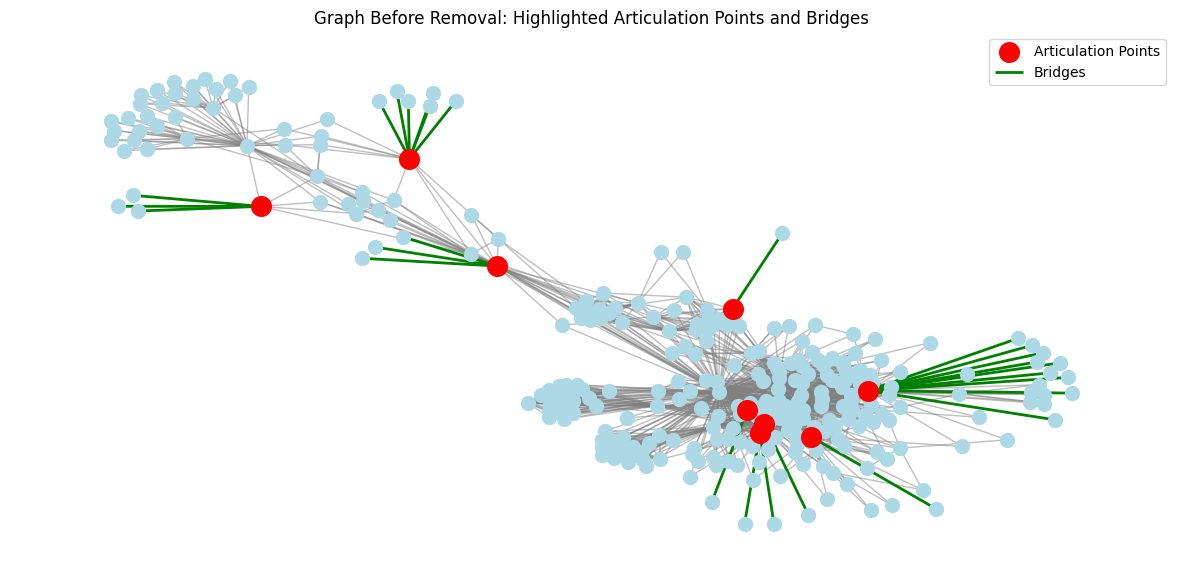

Removed articulation point: 12551
Removed bridge: (894976, 155046)


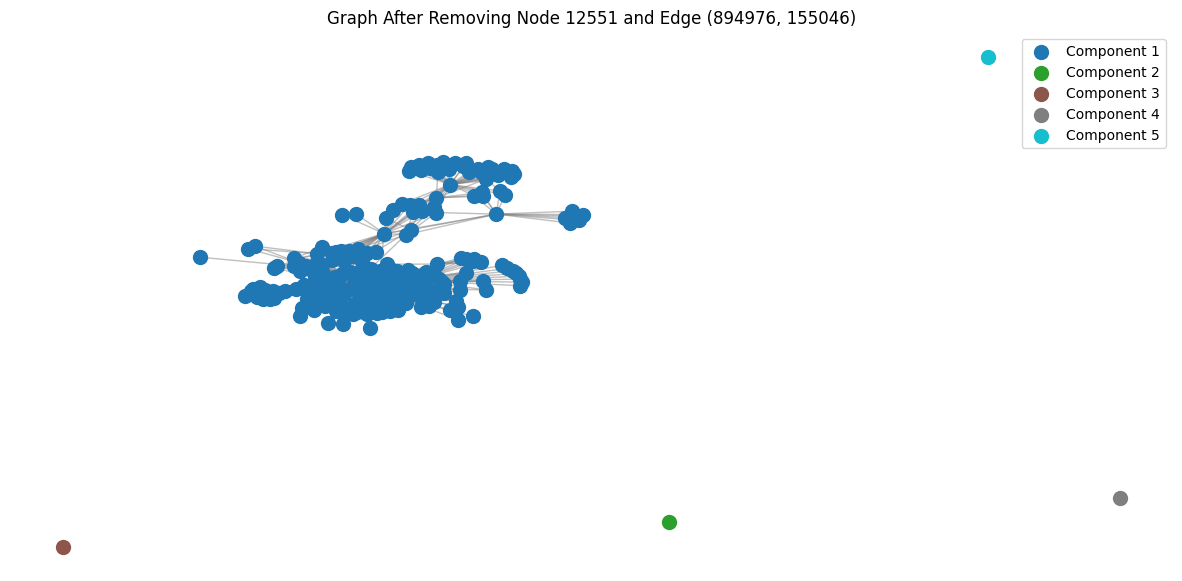

In [27]:
G_undirected_initial = G.to_undirected()

plt.figure(figsize=(15, 7))
pos_before = nx.spring_layout(G_undirected_initial)

nx.draw_networkx_nodes(G_undirected_initial, pos_before, node_color='lightblue', node_size=100)
nx.draw_networkx_edges(G_undirected_initial, pos_before, edge_color='gray', alpha=0.5)

nodes_to_highlight = [n for n in articulation_points if n in G_undirected_initial]
edges_to_highlight = [(u, v) for u, v in bridges if G_undirected_initial.has_edge(u, v)]

nx.draw_networkx_nodes(G_undirected_initial, pos_before, nodelist=nodes_to_highlight, node_color='red', node_size=200, label='Articulation Points')
nx.draw_networkx_edges(G_undirected_initial, pos_before, edgelist=edges_to_highlight, edge_color='green', width=2, label='Bridges')

plt.title('Graph Before Removal: Highlighted Articulation Points and Bridges')
plt.legend()
plt.axis('off')
plt.show()

G_modified = G_undirected_initial.copy()

removed_node = None
if articulation_points:
  removed_node = articulation_points[0]
  if G_modified.has_node(removed_node):
    G_modified.remove_node(removed_node)
    print(f"Removed articulation point: {removed_node}")
  else:
    print(f"Articulation point {removed_node} already removed or not found.")
else:
  print("No articulation points to remove.")

removed_bridge = None
if bridges:
  removed_bridge = bridges[0]
  if G_modified.has_edge(*removed_bridge):
    G_modified.remove_edge(*removed_bridge)
    print(f"Removed bridge: {removed_bridge}")
  else:
    print(f"Bridge {removed_bridge} already removed or not found.")
else:
  print("No bridges to remove.")

plt.figure(figsize=(15, 7))
pos_after = nx.spring_layout(G_modified)

new_components = list(nx.connected_components(G_modified))
colors = plt.get_cmap('tab10', len(new_components))

for i, component in enumerate(new_components):
  nx.draw_networkx_nodes(G_modified, pos_after, nodelist=list(component), node_color=[colors(i)], node_size=100, label=f'Component {i+1}')

nx.draw_networkx_edges(G_modified, pos_after, edge_color='gray', alpha=0.5)

plt.title(f'Graph After Removing Node {removed_node} and Edge {removed_bridge}')
plt.legend()
plt.axis('off')
plt.show()

The "before" visualization shows the original graph with key structural elements (articulation points and bridges) highlighted. These are nodes and edges that, if removed, would significantly impact the graph's connectivity.

The "after" visualization clearly demonstrates this impact. By removing just one articulation point and one bridge, the previously single connected component graph (when viewed as undirected) has split into multiple smaller components, confirming their critical role in maintaining the graph's overall connectivity.

Since the removal of a single node or edge significantly increases the number of components, it can be assumed that the graph sampled above is not redundant which could pose as a weakness.